## NYC Airbnb Listings Reproducible Data Workflow

- **Author:** Md Hafizur Rahman Bhuia
- **Dataset:** NYC Airbnb Listings
- **Dataset link:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

This project implements a complete, reproducible data-science workflow on the
NYC Airbnb listings dataset. It ingests the data, cleans and transforms it with
documented, reusable functions, runs exploratory analysis, and produces labeled
visualizations, all version-controlled with Git so that the entire workflow can be
rerun from scratch. No machine-learning models are trained; the focus is on a
clean, auditable data pipeline.



## Table of Contents
1. [Libraries & Setup](#setup)
2. [Data Ingestion](#ingestion)
3. [Data Cleaning](#cleaning)
4. [Exploratory Data Analysis](#eda)
5. [Visualizations](#visualizations)
6. [Summary & Interpretation](#summary)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")



---
## Data Ingestion
Import the libraries above, load the dataset with Pandas, and display the first
few rows to confirm the data loaded correctly.


In [2]:
# Load the local dataset (read-only)
DATA_FILE = Path("data/AB_NYC_2019.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_FILE}. Place the CSV in ./data.")

mb = DATA_FILE.stat().st_size / 1e6
load_date = datetime.now().strftime("%Y-%m-%d %H:%M")

df = pd.read_csv(DATA_FILE)

print(f"Loaded {DATA_FILE.name} -> {mb:.2f} MB on {load_date}")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded AB_NYC_2019.csv -> 7.08 MB on 2026-09-05 01:55
Dataset shape: 48895 rows, 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Data Cleaning
In this section, we perform data cleaning. First, let's check for duplicates and missing values:

In [3]:
print("No of duplicates:", df.duplicated().sum())

No of duplicates: 0


In [4]:
print(f"Missing values per column:\n{df.isna().sum()}")

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


There is a large amount of missing values in the fields last_review and reviews_per_month. This field is a candidate for imputation, when used used as a variable.

In [5]:
df.loc[df.last_review.isna(), 'reviews_per_month'] = 0.0

Next, we check for outliers in the numerical field price.

In [6]:
df[['price']].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


It turns out that there are far outliers in `price` field, which would distort correlation analysis and impede boxplot visualizations. We therefore remove them by cutting off at the 0.5% and 99.5% quantile:

In [7]:
price005 = np.quantile(df.price, q=0.005)
print(f'price 0.5% quantile: {price005}')
price995 = np.quantile(df.price, q=0.995)
print(f'price 99.5% quantile: {price995}')

price 0.5% quantile: 26.0
price 99.5% quantile: 1000.0


In [8]:
def clean_outliers(df, col, qLower, qUpper):
    """
    A function that removes outliers in a given columns, as specified by lower and upper cutoff values.
    
    Parameters
    ----------
        df (dataframe): The Pandas dataframe
        col (str): The column name
        qLower (float): The lower cutoff value
        qUpper (float): The upper cutoff value
        
    Returns
    -------
        pandas.DataFrame
            A copy of the frame with outliers removed.
    """
    df = df.copy()

    indices_to_drop = df[(df[col] < qLower) | (df[col] > qUpper)].index
    df.drop(indices_to_drop, inplace=True)

    return df

In [9]:
df = clean_outliers(df, 'price', price005, price995)

### 

In [10]:
print("There are not rentable rooms that are marked as `shared room` and should be removed from the dataset.")

df_not_rentable = df[df["room_type"].str.lower().str.contains("shared room", na=False)]
print("Not rentable rooms:", len(df_not_rentable))

There are not rentable rooms that are marked as `shared room` and should be removed from the dataset.
Not rentable rooms: 1047



**Dropping `shared room` listings** refocuses the analysis on whole-property nightly rates; this is a deliberate scope choice, not a data-loss issue.

In [11]:
def clean_non_rentable(df):
    """Drop non-rentable listing rows.

    This removes listings whose property type is not rentable by guests (e.g.
    shared rooms).

    Parameters
    ----------
    df : pandas.DataFrame
        Raw loaded dataset containing, at minimum, a 'room_type' column.

    Returns
    -------
    pandas.DataFrame
        A copy of the frame with non-rentable listings removed.
    """
    df = df.copy()
    
    if "room_type" in df.columns:
        df = df[~df["room_type"].str.lower().str.contains("shared room", na=False)]

    return df


In [12]:
df = clean_non_rentable(df)

print("Rows after cleaning:", len(df))
df.head()


Rows after cleaning: 47380


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Exploratory Data Analysis


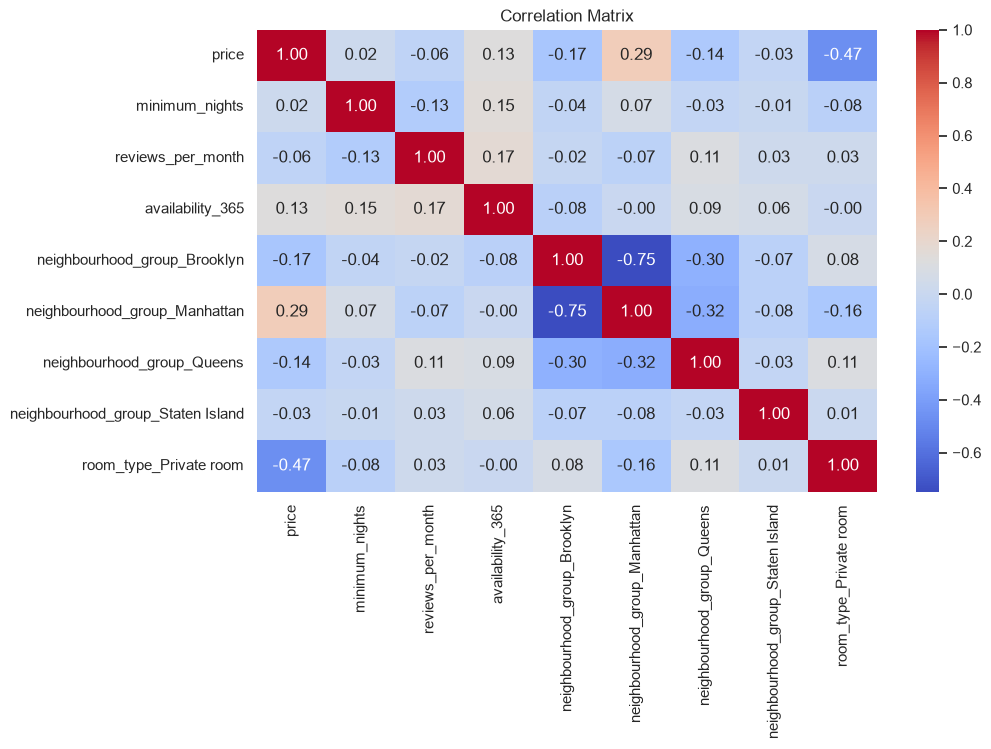

In [13]:
df_eda = df[['neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'reviews_per_month', 'availability_365']]
df_encoded = pd.get_dummies(df_eda, drop_first=True)

plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [14]:
print("Correlation of features with 'price':")
print(df_encoded.corr()['price'].abs().sort_values(ascending=False))

Correlation of features with 'price':
price                                1.000000
room_type_Private room               0.468473
neighbourhood_group_Manhattan        0.288343
neighbourhood_group_Brooklyn         0.171352
neighbourhood_group_Queens           0.143646
availability_365                     0.129218
reviews_per_month                    0.055562
neighbourhood_group_Staten Island    0.032246
minimum_nights                       0.020482
Name: price, dtype: float64


Next, we look at the categorial columns neighbourhood_group and room_type by producing grouped descriptive statistics:

In [15]:

def get_grouped_stats(df, stat_col, by_col):
    """
    A function that calculates descriptive statistics for a column in a dataframe, grouped by another column.
    
    Args:
        df (dataframe): The Pandas dataframe
        stat_col (str): Name of the column, for which stats are calculated
        by_col (str): Name of the column, by which data are grouped
        
    Returns:
        dataframe: A dataframe containing the grouped statistics
    """
    return df.groupby(by=by_col)[stat_col].describe()

In [16]:
get_grouped_stats(df, 'price', 'neighbourhood_group')

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1018.0,87.546169,76.037306,26.0,49.0,69.0,100.0,1000.0
Brooklyn,19579.0,119.520966,94.546437,26.0,60.0,95.0,150.0,1000.0
Manhattan,20985.0,181.179700,133.951001,26.0,98.0,150.0,220.0,1000.0
Queens,5439.0,96.765214,73.808851,26.0,53.0,75.0,115.0,1000.0
Staten Island,359.0,100.253482,97.019982,27.0,50.0,75.0,110.0,1000.0


In [17]:
get_grouped_stats(df, 'price', 'room_type')

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25195.0,194.762493,126.049295,28.0,120.0,160.0,225.0,1000.0
Private room,22185.0,85.036511,68.750757,26.0,50.0,70.0,95.0,1000.0


These statistics indicate a clear dependence of the price on both the neighbourhood (Manhatten is most expensive on average and the Bronx is cheapest on average) and the room type (entire apartments are significantly more expensive on average than private or shared rooms).


---
## Visualizations

### Univariate Distributions
We first look at univariate distributions of the variables under consideration.

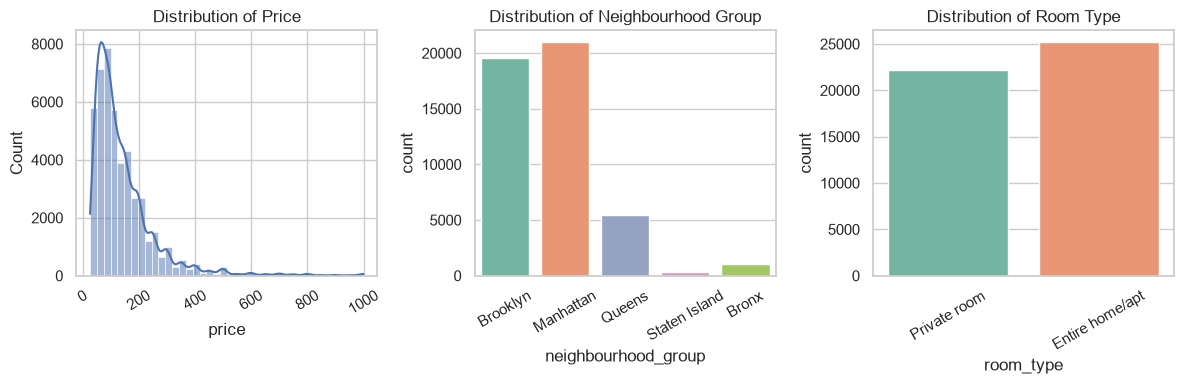

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(df['price'], ax=axes[0], bins=40, kde=True)
axes[0].set_title("Distribution of Price")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(
    x="neighbourhood_group",
    hue="neighbourhood_group",
    data=df, ax=axes[1],
    palette="Set2",
    legend=False
)
axes[1].set_title("Distribution of Neighbourhood Group")
axes[1].tick_params(axis='x', rotation=30)

sns.countplot(
    x="room_type",
    hue="room_type",
    data=df,
    ax=axes[2],
    palette="Set2",
    legend=False
)
axes[2].set_title("Distribution of Room Type")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Observations**:
* Most entries have prices below USD 200, with outliers out to USD 1,000
* Most entries are based in Manhattan or Brooklyn, some in Queens, and comparably few in Staten Island and the Bronx
* Private room count and Entire home/Apt count is mostly same.

### Bivariate Plots
Next we look at bivariate plots, visualizing the dependence of price on the other variables.

#### Median Nightly Airbnb Price by Neighbourhood Group

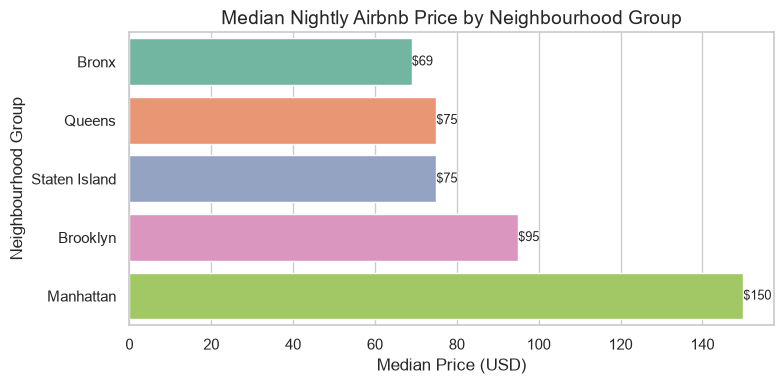

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

group_stats = df.groupby("neighbourhood_group")["price"].agg(["median", "std"])
group_stats = group_stats.sort_values("median")

sns.barplot(
    data=group_stats.reset_index(),
    y="neighbourhood_group",
    x="median",
    hue="neighbourhood_group",
    palette="Set2",
    legend=False,
    ax=ax
)

for i, row in group_stats.iterrows():
    ax.text(row["median"], i, f"${row['median']:,.0f}",
            va="center", ha="left", fontsize=9)

ax.set_title("Median Nightly Airbnb Price by Neighbourhood Group", fontsize=14)
ax.set_xlabel("Median Price (USD)")
ax.set_ylabel("Neighbourhood Group")

plt.tight_layout()
plt.savefig("charts/figure1_price_by_neighbourhood.png", dpi=120)
plt.show()

**Observations:**
* Manhattan typically commands the highest median nightly rate, followed by the outer boroughs, with the variation between neighbourhoods reflecting demand, transportation access, and
tourist density.
* Lower median prices indicate more affordable or less centrally located housing stock.


#### Price Distribution by Neighbourhood Group

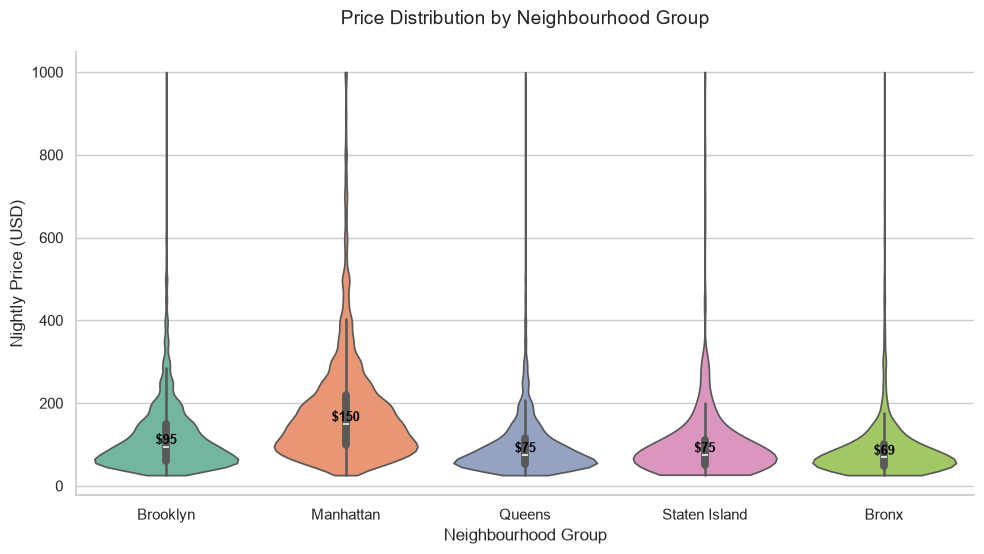

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",
    palette="Set2",
    dodge=False,
    inner="box",
    cut=0,
    density_norm="width",
    legend=False,
    ax=ax
)

# Compute medians
medians = df.groupby("neighbourhood_group")["price"].median()

# Adjust label placement dynamically
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    group = label.get_text()
    median_val = medians[group]
    ax.text(
        tick,
        median_val,
        f"${median_val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

#
ax.set_title("Price Distribution by Neighbourhood Group", fontsize=14, pad=20)
ax.set_xlabel("Neighbourhood Group", fontsize=12)
ax.set_ylabel("Nightly Price (USD)", fontsize=12)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leaves extra space for title
plt.savefig("charts/figure2_price_violin.png", dpi=120)
plt.show()



**Observations:**
* The plot demonstrates pronounced right skew in Airbnb pricing across New York City.
* Manhattan and Brooklyn exhibit the widest distributions, driven by luxury listings, while outer boroughs remain tightly clustered around lower price points.

#### Price by Property Type Across Neighbourhood Groups

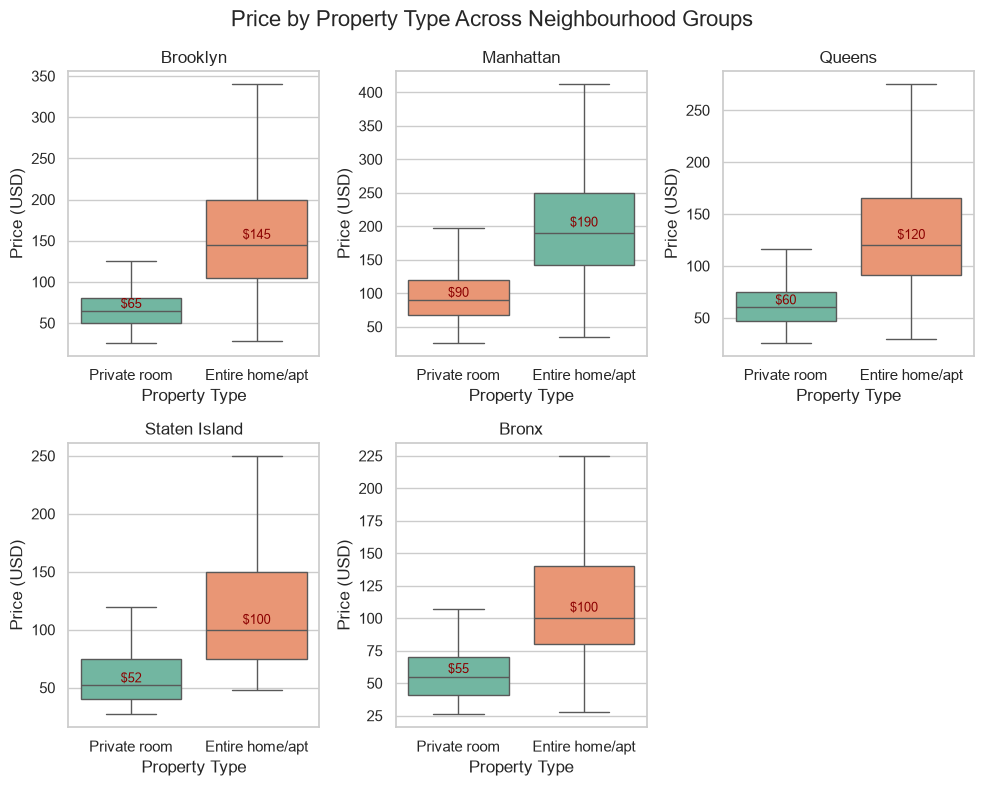

In [26]:
# Compute medians for annotation
medians = df.groupby(["neighbourhood_group", "room_type"])["price"].median().unstack()

groups = ["Brooklyn", "Manhattan", "Queens", "Staten Island", "Bronx"]
order = ["Private room", "Entire home/apt"]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    subset = df[df["neighbourhood_group"] == group]

    sns.boxplot(
        data=subset,
        x="room_type",
        y="price",
        hue="room_type",
        order=order,
        palette="Set2",
        showfliers=False,
        legend=False,
        ax=ax
    )

    ax.set_title(group)
    ax.set_xlabel("Property Type")
    ax.set_ylabel("Price (USD)")
    ax.tick_params(axis="x", rotation=0)

    # Add median annotations
    for i, room in enumerate(order):
        val = medians.loc[group, room]
        if not np.isnan(val):
            ax.text(
                i,
                val + (val * 0.05),
                f"${val:.0f}",
                ha="center",
                fontsize=9,
                color="darkred"
            )

# Remove empty subplot (6th)
fig.delaxes(axes[-1])

fig.suptitle("Price by Property Type Across Neighbourhood Groups", fontsize=16)
plt.tight_layout()
plt.show()


**Observations:**
* The plots reveal strong price stratification across New York City boroughs and property types.
* Manhattan commands the highest median prices, while Staten Island and the Bronx remain the most affordable.
* It  highlights wide variability within boroughs, especially Manhattan, where entire apartments reach luxury price levels.
* In contrast, outer boroughs show tighter distributions, indicating more uniform pricing.
* These patterns underscore the influence of both location and property type on Airbnb pricing.


---
**What I learned.** The dataset captures the economics of short-term rentals
across NYC, with geography (neighbourhood group) and property type as the two
strongest predictors of price.

**Limitations.** TBD

**Surprising / unclear.** TBD
